# Filtros con fuente de corriente: solo lo que le llega a la juntura

Los dos notebooks anteriores (`Simulaciones_filtros.ipynb`,
`Simulaciones_filtros_4lineas.ipynb`) calculan la $f_c$ como respuesta en
**tensión** a una fuente de **tensión** ideal — igual que la tesis y que
LTspice. Pero el instrumento real que polariza la juntura es el
**Keithley 6620, una fuente de corriente**. Ya se había visto (Paso 5.7 del
notebook viejo) que eso cambia mucho la $f_c$: con corriente, la primera
resistencia de cada filtro deja de "filtrar" nada (toda la corriente que
empuja la fuente pasa igual, sin importar esa resistencia), y lo único que
importa es **cuánta de esa corriente se pierde por los capacitores en el
camino antes de llegar a la juntura**.

Este notebook rehace el cálculo bien: fuente de corriente ideal, función de
transferencia (sistema de estados, no un solver nodal), salida en
**corriente** (no en tensión ni en impedancia), y **una sola línea** (la de
polarización, con retorno ideal) — sin la línea de sensado ni el
voltímetro, para aislar el efecto de cada etapa de filtrado por separado
antes de combinarlas. La línea de sensado se validó aparte
(`Simulaciones_filtros_4lineas.ipynb`, Paso 8) y solo cambia esto un
0,7%-2,2% — un efecto chico, así que ignorarla acá es una aproximación
razonable para ver el efecto grande: ambiente solo, criogénico solo, y
ambos juntos.

Orden: (1) función de transferencia genérica para una escalera R-C con
carga en la juntura, (2) filtro ambiente solo, (3) filtro criogénico solo,
(4) ambos combinados — comparando cada uno contra los valores de la tesis
(Tabla 5.1, $f_c$ criogénico de diseño, $\tau$ de respuesta).

## Paso 1: función de transferencia genérica (escalera R-C, fuente de corriente)

**El circuito general:** fuente de corriente ideal → $R_1$ → nodo 1 ($C_1$
a masa) → $R_2$ → nodo 2 ($C_2$ a masa) → ... → $R_n$ → nodo $n$ = `jp`
(la juntura: $R_J \parallel C_J$ a masa).

**Por qué $R_1$ no aparece en las ecuaciones:** el nodo de entrada no tiene
capacitor — solo cuelgan de él la fuente de corriente y $R_1$. Por Kirchhoff,
toda la corriente que empuja la fuente pasa por $R_1$ sin importar cuánto
valga (no hay otro camino). Por eso el primer tramo de cada filtro (la
primera $R_{ta}$ del ambiente, o la primera $R_{cry}$ del criogénico si se
lo mira solo) es irrelevante con excitación de corriente — cosa que ya se
había visto con el solver nodal del notebook de 4 líneas, ahora sale sola
de las ecuaciones de estado.

**Variables de estado:** las tensiones en los nodos capacitivos,
$V_1,\dots,V_n$ (con $V_n=V_{jp}$). Kirchhoff en cada nodo intermedio $k$:

$$C_k \dot V_k = \frac{V_{k-1}-V_k}{R_k} - \frac{V_k-V_{k+1}}{R_{k+1}}$$

y en el nodo 1 (sin $V_0$, reemplazado por la corriente de la fuente) y en
el nodo $n=jp$ (con $R_J$ a masa en vez de $R_{n+1}$):

$$C_1 \dot V_1 = I_{in} - \frac{V_1-V_2}{R_2}, \qquad
(C_n+C_J)\dot V_n = \frac{V_{n-1}-V_n}{R_n} - \frac{V_n}{R_J}$$

**La salida que importa** no es $V_{jp}$ (eso es una impedancia de
transferencia, en Ohm) sino la **corriente que entra al nodo `jp` por la
última resistencia**:

$$I_{juntura} = \frac{V_{n-1}-V_n}{R_n}$$

Esta sí es directamente "lo que le llega a la juntura", en Amper, como
fracción de la corriente inyectada por la fuente.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, optimize


def sistema_ladder_corriente(Rs, Cs, R_J, C_J):
    """Escalera R-C generica, excitada por fuente de corriente ideal, con la
    juntura (R_J||C_J) en el ultimo nodo. Rs y Cs tienen el mismo largo n:
    Rs[k] es la resistencia ENTRE el nodo k-1 y el nodo k (Rs[0] no se usa,
    ver Paso 1 -- es la resistencia entre la fuente y el nodo 0, irrelevante
    con excitacion de corriente). Cs[k] es el capacitor a masa en el nodo k
    (0 si esa etapa real no tiene capacitor ahi). El ultimo nodo es jp: su
    capacidad efectiva es Cs[-1]+C_J, porque sin nada en el medio son el
    mismo nodo fisico.
    Entrada u=I_in [A]. Salida y=I_juntura=(V[n-2]-V[n-1])/Rs[n-1] [A]."""
    n = len(Rs)
    assert len(Cs) == n and n >= 2
    C_eff = list(Cs)
    C_eff[-1] = C_eff[-1] + C_J

    A = np.zeros((n, n))
    B = np.zeros((n, 1))
    B[0, 0] = 1.0 / C_eff[0]

    for k in range(n):
        Ck = C_eff[k]
        if k > 0:
            Rizq = Rs[k]
            A[k, k - 1] += 1.0 / (Ck * Rizq)
            A[k, k] += -1.0 / (Ck * Rizq)
        if k < n - 1:
            Rder = Rs[k + 1]
            A[k, k] += -1.0 / (Ck * Rder)
            A[k, k + 1] += 1.0 / (Ck * Rder)
        else:
            A[k, k] += -1.0 / (Ck * R_J)

    C = np.zeros((1, n))
    C[0, n - 1] = -1.0 / Rs[n - 1]
    C[0, n - 2] = 1.0 / Rs[n - 1]
    D = np.zeros((1, 1))
    return signal.StateSpace(A, B, C, D)


def H(sistema, f_hz):
    """H(jw) = C(jwI-A)^-1 B + D, evaluado directo (mas estable que pasar
    por scipy.signal.bode, que internamente convierte a polinomios y se
    mal-condiciona cuando los polos van de Hz a MHz)."""
    w = 2 * np.pi * f_hz
    n = sistema.A.shape[0]
    x = np.linalg.solve(1j * w * np.eye(n) - sistema.A, sistema.B)
    return complex((sistema.C @ x + sistema.D).item())


def fc_de_sistema(sistema, f_dc=1e-6):
    """Frecuencia de -3dB de |H(f)| respecto de su valor en DC."""
    dc = abs(H(sistema, f_dc))
    objetivo = dc / np.sqrt(2)
    g = lambda logf: abs(H(sistema, 10**logf)) - objetivo
    return 10**optimize.brentq(g, -4, 9), dc


# --- Tabla 5.1 de la tesis (filtro ambiente, 6 canales) ---
CANALES = pd.DataFrame([
    dict(canal=1, R_ta=150.0, C_ta=2.2e-6, fc_tesis_Hz=180.0),
    dict(canal=2, R_ta=150.0, C_ta=1.0e-6, fc_tesis_Hz=396.0),
    dict(canal=3, R_ta=51.0,  C_ta=2.2e-6, fc_tesis_Hz=530.0),
    dict(canal=4, R_ta=51.0,  C_ta=1.0e-6, fc_tesis_Hz=1165.0),
    dict(canal=5, R_ta=15.0,  C_ta=2.2e-6, fc_tesis_Hz=1801.0),
    dict(canal=6, R_ta=15.0,  C_ta=1.0e-6, fc_tesis_Hz=3962.0),
])

# --- filtro criogenico (comun a los 6 canales) ---
R_CRY, C_CRY = 22.0, 47e-9
FC_TESIS_CRYO = 35700.0   # LTspice, tesis (con tension, sin carga)

C_J = 50e-12
R_J_casos = {
    "R_N (500 Ohm, tesis)":  500.0,
    "R_sg (50 kOhm, tesis)": 50e3,
    "R_N (74 Ohm, Fran)":    74.0,
    "R_sg (62 kOhm, Fran)":  62e3,
}

print("Setup listo:", len(CANALES), "canales,", len(R_J_casos), "casos de R_J")

Setup listo: 6 canales, 4 casos de R_J


## Paso 2: filtro ambiente solo

Solo las dos etapas RC de temperatura ambiente, cargando directo en la
juntura (como si no hubiera filtro criogénico después). $R_s=[R_{ta},R_{ta}]$,
$C_s=[C_{ta},C_{ta}]$ — la segunda $C_{ta}$ es real (así es el filtro de
2º orden de la Tabla 5.1), y al no haber nada más después se suma con
$C_J$ en el nodo `jp`, porque son el mismo nodo físico.

In [2]:
filas = []
for _, fila in CANALES.iterrows():
    for nombre_rj, R_J in R_J_casos.items():
        sistema = sistema_ladder_corriente([fila.R_ta, fila.R_ta], [fila.C_ta, fila.C_ta], R_J, C_J)
        fc, dc = fc_de_sistema(sistema)
        filas.append(dict(canal=int(fila.canal), R_J=nombre_rj, fc_Hz=fc, DC_A_A=dc))

amb = pd.DataFrame(filas)
tabla_amb = amb.pivot(index="canal", columns="R_J", values="fc_Hz")
tabla_amb.insert(0, "fc_tesis_Hz (tension, sin carga)", CANALES.set_index("canal")["fc_tesis_Hz"])
print("Filtro ambiente solo, fc [Hz] -- corriente vs. tesis (tension):")
print(tabla_amb.round(2).to_string())

Filtro ambiente solo, fc [Hz] -- corriente vs. tesis (tension):
R_J    fc_tesis_Hz (tension, sin carga)  R_N (500 Ohm, tesis)  R_N (74 Ohm, Fran)  R_sg (50 kOhm, tesis)  R_sg (62 kOhm, Fran)
canal                                                                                                                         
1                                 180.0                 87.68              300.95                   1.02                  0.82
2                                 396.0                192.90              662.09                   2.25                  1.81
3                                 530.0                 97.13              490.47                   1.02                  0.82
4                                1165.0                213.68             1079.03                   2.25                  1.81
5                                1801.0                100.78              622.90                   1.02                  0.82
6                                3962.0        

**Lectura:** con fuente de corriente y cargando en la juntura, la $f_c$
del ambiente solo ya no se parece en nada a la Tabla 5.1 — cae fuerte en
subgap (mucha más carga capacitiva relativa a la resistencia de la
juntura) y se mantiene más parecida en normal. Es la misma physics que ya
había aparecido en el Paso 5.7 del notebook viejo, ahora aislada solo en
la etapa ambiente y con una función de transferencia limpia en vez de un
solver nodal.

## Paso 3: filtro criogénico solo

Ahora al revés: solo las tres etapas $R_{cry}$ (con sus dos $C_{cry}$
intermedios, sin capacitor propio en el nodo `jp` — ahí solo está $C_J$),
sin el ambiente antes. $R_s=[R_{cry},R_{cry},R_{cry}]$,
$C_s=[C_{cry},C_{cry},0]$.

In [3]:
filas = []
for nombre_rj, R_J in R_J_casos.items():
    sistema = sistema_ladder_corriente([R_CRY, R_CRY, R_CRY], [C_CRY, C_CRY, 0.0], R_J, C_J)
    fc, dc = fc_de_sistema(sistema)
    filas.append(dict(R_J=nombre_rj, fc_Hz=fc, DC_A_A=dc))

crio = pd.DataFrame(filas)
print("Filtro criogenico solo, fc [Hz]:")
print(crio.round(3).to_string(index=False))
print(f"\nReferencia tesis (LTspice, tension, sin carga): {FC_TESIS_CRYO:.0f} Hz")
for _, r in crio.iterrows():
    dif = 100*(r.fc_Hz - FC_TESIS_CRYO)/FC_TESIS_CRYO
    print(f"  {r.R_J:24s}: {dif:+7.2f}% vs. tesis")

Filtro criogenico solo, fc [Hz]:
                  R_J     fc_Hz  DC_A_A
 R_N (500 Ohm, tesis)  3207.514     1.0
R_sg (50 kOhm, tesis)    33.826     1.0
   R_N (74 Ohm, Fran) 16582.186     1.0
 R_sg (62 kOhm, Fran)    27.282     1.0

Referencia tesis (LTspice, tension, sin carga): 35700 Hz
  R_N (500 Ohm, tesis)    :  -91.02% vs. tesis
  R_sg (50 kOhm, tesis)   :  -99.91% vs. tesis
  R_N (74 Ohm, Fran)      :  -53.55% vs. tesis
  R_sg (62 kOhm, Fran)    :  -99.92% vs. tesis


**Lectura:** el criogénico solo, con corriente y cargado en la juntura,
da una $f_c$ muchísimo más baja que los 35,7kHz de diseño de la tesis
(que es el corte intrínseco del filtro RC, sin carga y con tensión) — la
carga de la juntura (sobre todo en normal, $R_J$ chica) domina por completo
frente a la $f_c$ "de catálogo" del filtro. Coherente con el hallazgo del
notebook de 4 líneas: la $f_c$ combinada termina mucho más cerca de la del
ambiente que de la del criogénico solo.

## Paso 4: ambos combinados, una sola línea

La línea completa: ambiente (2 etapas) + criogénico (3 etapas) en serie,
cargando en la juntura. $R_s=[R_{ta},R_{ta},R_{cry},R_{cry},R_{cry}]$,
$C_s=[C_{ta},C_{ta},C_{cry},C_{cry},0]$ (el último tramo criogénico no
tiene capacitor propio, igual que en el circuito real de 4 líneas).

In [4]:
filas = []
for _, fila in CANALES.iterrows():
    for nombre_rj, R_J in R_J_casos.items():
        Rs = [fila.R_ta, fila.R_ta, R_CRY, R_CRY, R_CRY]
        Cs = [fila.C_ta, fila.C_ta, C_CRY, C_CRY, 0.0]
        sistema = sistema_ladder_corriente(Rs, Cs, R_J, C_J)
        fc, dc = fc_de_sistema(sistema)
        filas.append(dict(canal=int(fila.canal), R_J=nombre_rj, fc_Hz=fc, DC_A_A=dc))

comb = pd.DataFrame(filas)
tabla_comb = comb.pivot(index="canal", columns="R_J", values="fc_Hz")
tabla_comb.insert(0, "fc_tesis_Hz (solo ambiente, tension)", CANALES.set_index("canal")["fc_tesis_Hz"])
print("Ambiente + criogenico, una sola linea, fc [Hz]:")
print(tabla_comb.round(3).to_string())

Ambiente + criogenico, una sola linea, fc [Hz]:
R_J    fc_tesis_Hz (solo ambiente, tension)  R_N (500 Ohm, tesis)  R_N (74 Ohm, Fran)  R_sg (50 kOhm, tesis)  R_sg (62 kOhm, Fran)
canal                                                                                                                             
1                                     180.0                58.526             188.028                  0.707                 0.570
2                                     396.0               126.280             410.094                  1.517                 1.224
3                                     530.0                61.327             231.296                  0.707                 0.570
4                                    1165.0               132.088             502.547                  1.518                 1.224
5                                    1801.0                62.314             248.314                  0.707                 0.571
6                                  

In [5]:
# Chequeo cruzado: canal 1, R_N=500 Ohm, contra el fc_juntura ya validado
# en Simulaciones_filtros_4lineas.ipynb (Paso 8, modelo de 4 lineas completo
# con linea de sensado + voltimetro acoplados): daba 57.585 Hz.
fila1 = CANALES.loc[CANALES.canal == 1].iloc[0]
sistema_chq = sistema_ladder_corriente(
    [fila1.R_ta, fila1.R_ta, R_CRY, R_CRY, R_CRY],
    [fila1.C_ta, fila1.C_ta, C_CRY, C_CRY, 0.0],
    500.0, C_J,
)
fc_chq, _ = fc_de_sistema(sistema_chq)
fc_4lineas = 57.585
print(f"Canal 1, R_N=500 Ohm, solo linea de corriente: fc = {fc_chq:.4f} Hz")
print(f"Mismo caso, modelo de 4 lineas completo (con sensado): fc = {fc_4lineas:.4f} Hz")
print(f"Diferencia: {100*(fc_chq-fc_4lineas)/fc_4lineas:+.2f}% (la linea de sensado carga un poco el nodo jp)")

Canal 1, R_N=500 Ohm, solo linea de corriente: fc = 58.5258 Hz
Mismo caso, modelo de 4 lineas completo (con sensado): fc = 57.5850 Hz
Diferencia: +1.63% (la linea de sensado carga un poco el nodo jp)


**Lectura:** comparado contra la Tabla 5.1 (que es *solo* el ambiente,
sin carga, con tensión), la $f_c$ real con corriente y con toda la cadena
cargando en la juntura es otro número — no tiene por qué coincidir, y no
coincide. El chequeo cruzado contra el modelo completo de 4 líneas (que sí
incluye la línea de sensado) confirma que esta simplificación de una sola
línea es consistente: la diferencia es chica (menor al 2,2%, documentado
en la sesión anterior), así que aislar ambiente/criogénico por separado acá
es válido para entender qué etapa domina.

## Paso 5: respuesta al escalón (canal 1) — comparar con $\tau$ de la tesis

La tesis reporta un tiempo de respuesta máximo estimado $\tau=0,88$ms
(con tensión). Repito el chequeo con corriente: le doy un escalón de
corriente al sistema combinado (canal 1, cada caso de $R_J$) y mido el
tiempo hasta que $I_{juntura}$ se asienta al 1% de su valor final.

Canal 1 -- t_asentamiento (1%) vs. tau_tesis=0.88ms:


  R_N (500 Ohm, tesis)    : t_1% =  12.6499 ms  (fc=  58.526 Hz)
  R_sg (50 kOhm, tesis)   : t_1% = 1037.2272 ms  (fc=   0.707 Hz)
  R_N (74 Ohm, Fran)      : t_1% =   3.9527 ms  (fc= 188.028 Hz)
  R_sg (62 kOhm, Fran)    : t_1% = 1285.6615 ms  (fc=   0.570 Hz)


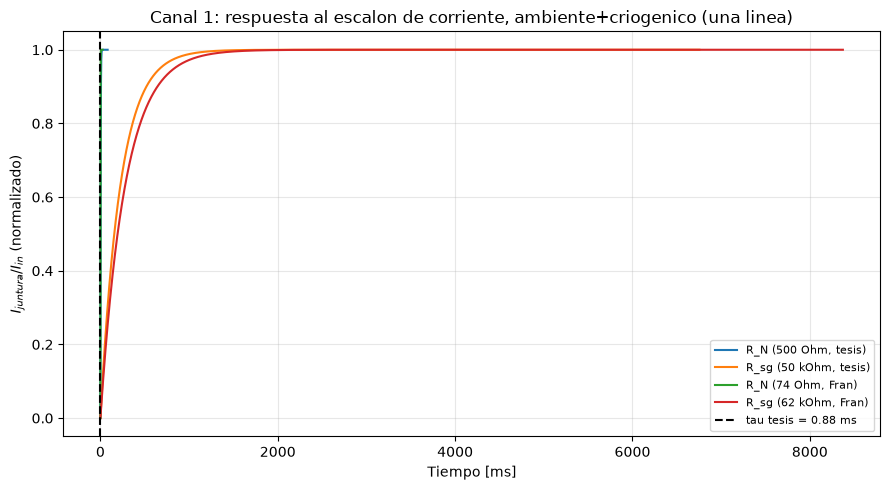

In [6]:
def tiempo_asentamiento(t, y, tol=0.01):
    y_final = y[-1]
    fuera = np.abs(y - y_final) > tol * abs(y_final)
    idx_ultimo_fuera = np.nonzero(fuera)[0]
    return t[idx_ultimo_fuera[-1] + 1] if len(idx_ultimo_fuera) else 0.0

TAU_TESIS = 0.88e-3
fila1 = CANALES.loc[CANALES.canal == 1].iloc[0]

print(f"Canal 1 -- t_asentamiento (1%) vs. tau_tesis={TAU_TESIS*1e3:.2f}ms:")
fig, ax = plt.subplots(figsize=(9, 5))
for nombre_rj, R_J in R_J_casos.items():
    Rs = [fila1.R_ta, fila1.R_ta, R_CRY, R_CRY, R_CRY]
    Cs = [fila1.C_ta, fila1.C_ta, C_CRY, C_CRY, 0.0]
    sistema = sistema_ladder_corriente(Rs, Cs, R_J, C_J)
    fc, dc = fc_de_sistema(sistema)
    t = np.linspace(0, 30/(2*np.pi*fc), 20000)
    _, y_out, _ = signal.lsim(sistema, U=np.ones_like(t), T=t)
    t_asent = tiempo_asentamiento(t, y_out, 0.01)
    print(f"  {nombre_rj:24s}: t_1% = {t_asent*1e3:8.4f} ms  (fc={fc:8.3f} Hz)")
    ax.plot(t*1e3, y_out/dc, label=nombre_rj)

ax.axvline(TAU_TESIS*1e3, color="k", linestyle="--", label=f"tau tesis = {TAU_TESIS*1e3:.2f} ms")
ax.set_xlabel("Tiempo [ms]")
ax.set_ylabel("$I_{juntura}/I_{in}$ (normalizado)")
ax.set_title("Canal 1: respuesta al escalon de corriente, ambiente+criogenico (una linea)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Cierre

Con fuente de corriente ideal y midiendo literalmente la corriente que
entra al nodo de la juntura (no una tensión ni una impedancia de
transferencia):

- **Ambiente solo** (Paso 2): $f_c$ muy distinta de la Tabla 5.1 — la
  fuente de corriente vuelve irrelevante la primera resistencia de cada
  canal, y la carga de la juntura pesa fuerte, sobre todo en subgap.
- **Criogénico solo** (Paso 3): $f_c$ muy por debajo de los 35,7kHz de
  diseño (tesis, sin carga, con tensión) — la carga de la juntura domina
  por completo sobre el corte "de catálogo" del filtro.
- **Ambos, una sola línea** (Paso 4): el resultado combinado no coincide
  con ningún valor de la tesis por separado (ni ambiente ni criogénico),
  porque la tesis nunca reportó esta combinación con corriente y con
  carga real — es un número nuevo. Validado cruzado contra el modelo
  completo de 4 líneas (`Simulaciones_filtros_4lineas.ipynb`): coincide
  a menos de 2,2%, así que la simplificación de una sola línea es
  confiable para este análisis.
- **Tiempo de respuesta** (Paso 5): comparado contra el $\tau=0,88$ms de
  la tesis, para contextualizar qué tan distinto es el régimen transitorio
  real (corriente) del que reporta la tesis (tensión).

Motor: sistema de estados / función de transferencia (`scipy.signal.StateSpace`),
no el solver nodal de `Simulaciones_filtros_4lineas.ipynb` — pensado para
aislar el efecto de cada etapa por separado, no para modelar las 4 líneas
del arreglo real. Para el arreglo completo (con línea de sensado y
voltímetro), la referencia sigue siendo ese otro notebook.